In [1]:
from typing import Dict, TypedDict, List, Annotated, Sequence
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage, BaseMessage
from dotenv import load_dotenv


C:\code\NL_2_DST\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [10]:
from typing import Optional
from typing_extensions import TypedDict

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END

import instructor
from openai import OpenAI


# -------------------------
# 1. Structured output schema
# -------------------------

class Actor(BaseModel):
    name: str = Field(..., description="Actor name exactly as referred to in the text")
    actor_type: str = Field(
        ...,
        description="Actor type, e.g. Person, Group, System"
    )


class WorkObject(BaseModel):
    name: str = Field(..., description="Work object name from the text")
    object_type: str = Field(
        ...,
        description="General type such as document, form, data, email, request, report"
    )
    description: str = Field(
        ...,
        description=(
            "Short semantic description of what the object is, focusing on its function "
            "and general category, especially the head noun."
        )
    )


class Activity(BaseModel):
    step: int = Field(..., description="Activity step number")
    actor: str = Field(..., description="Actor performing the activity")
    verb: str = Field(..., description="Verb describing the activity")
    work_object: str = Field(..., description="Work object involved in the activity")
    preposition: Optional[str] = Field(None, description="Optional preposition for the activity")
    involved_actor: Optional[str] = Field(None, description="Optional second actor involved in the activity")


class DomainStoryElements(BaseModel):
    # actors: list[Actor] = Field(default_factory=list)
    # work_objects: list[WorkObject] = Field(default_factory=list)
    activities: list[Activity] = Field(default_factory=list)


# -------------------------
# 2. LangGraph state
# -------------------------

class AgentState(TypedDict):
    text: str
    extracted_elements: Optional[DomainStoryElements]
    error: Optional[str]


# -------------------------
# 3. Model client
# -------------------------

client = instructor.from_openai(OpenAI())

system_prompt = """
You extract Domain Story elements from the given text.

Return:
- all detected actors
- all detected work objects

Rules:
- Keep names concise
- Do not invent elements not supported by the text
- actor_type should be one of: Person, Group, System
- object_type should be a short generic noun such as: document, email, form, data, item, request, report
"""


# -------------------------
# 4. Extraction node
# -------------------------

def extraction_node(state: AgentState) -> AgentState:
    try:
        result = client.chat.completions.create(
            model="gpt-4o",
            response_model=DomainStoryElements,
            temperature=0,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": state["text"]},
            ],
        )

        return {
            "extracted_elements": result,
            "error": None,
        }

    except Exception as e:
        return {
            "extracted_elements": None,
            "error": str(e),
        }


# -------------------------
# 5. Build graph
# -------------------------

graph = StateGraph(AgentState)

graph.add_node("extraction_node", extraction_node)
graph.add_edge(START, "extraction_node")
graph.add_edge("extraction_node", END)

agent = graph.compile()

# -------------------------
# 6. Example run
# -------------------------

result = agent.invoke(
    {
        "text": "The customer sends an order form to the sales department. "
                "The sales employee checks the form and enters the data into the ERP system."
    }
)

print(result)

{'text': 'The customer sends an order form to the sales department. The sales employee checks the form and enters the data into the ERP system.', 'extracted_elements': DomainStoryElements(activities=[Activity(step=1, actor='Customer', verb='send', work_object='order form', preposition='to', involved_actor='Sales Department'), Activity(step=2, actor='Sales Employee', verb='check', work_object='form', preposition=None, involved_actor=None), Activity(step=3, actor='Sales Employee', verb='enter', work_object='data', preposition='into', involved_actor='ERP System')]), 'error': None}


In [11]:
print(result["extracted_elements"].model_dump())

{'activities': [{'step': 1, 'actor': 'Customer', 'verb': 'send', 'work_object': 'order form', 'preposition': 'to', 'involved_actor': 'Sales Department'}, {'step': 2, 'actor': 'Sales Employee', 'verb': 'check', 'work_object': 'form', 'preposition': None, 'involved_actor': None}, {'step': 3, 'actor': 'Sales Employee', 'verb': 'enter', 'work_object': 'data', 'preposition': 'into', 'involved_actor': 'ERP System'}]}


In [4]:
# Extraction Node
def extract_elements(user_input: str):
    """Extracts elements from the user input."""
    # This is a placeholder implementation. You can replace it with actual logic to extract elements.
    pass


# Icon search Node
def search_icons():
    pass


# PlantUML Generation Node
def generate_plantuml(elements: Dict[str, List[str]]) -> str:
    """Generates PlantUML code from the extracted elements."""
    pass


# Syntax validation Node
def validate_plantuml(plantuml_code: str) -> bool:
    """Validates the generated PlantUML code."""
    pass


# Conditional Node
def is_valid(plantuml_code: str) -> bool:
    """Checks if the PlantUML code is valid."""
    pass

# tools = [extract_elements, generate_plantuml]

In [5]:
llm = ChatOpenAI(model="gpt-4o")

system_prompt = """
You extract Domain Story elements from the given text.
Return these detected actors and work objects=
"""


def model_node(state: AgentState) -> AgentState:
    messages = list(state["messages"])
    messages = [SystemMessage(content=system_prompt)] + messages
    message = llm.invoke(messages)
    return {"message": [message]}




In [6]:
graph = StateGraph(AgentState)
graph.add_node("model_node", model_node)
graph.add_node("extraction_node", extract_elements)
graph.add_node("icon_search_node", search_icons)
graph.add_node("plantuml_generation_node", generate_plantuml)
graph.add_node("validation_node", validate_plantuml)

graph.set_entry_point("model_node")
graph.add_edge("model_node", "extraction_node")
graph.add_edge("extraction_node", "icon_search_node")
graph.add_edge("icon_search_node", "plantuml_generation_node")
graph.add_edge("plantuml_generation_node", "validation_node")

graph.add_conditional_edges("validation_node", is_valid, {"valid": END, "invalid": "plantuml_generation_node"})
agent = graph.compile()

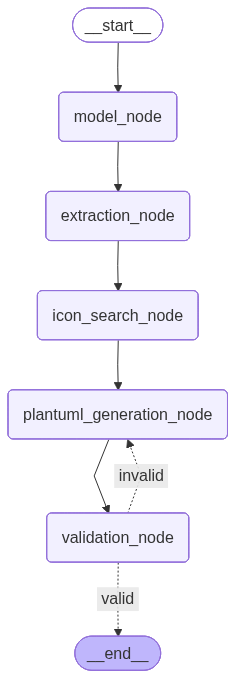

In [7]:
from IPython.display import display, Image

display(Image(agent.get_graph().draw_mermaid_png()))